In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden
from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter

# Use the provided mplstyle if available
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: lamalab.mplstyle not found. Using default Matplotlib style.")

# --- Constants ---
TWO_COL_WIDTH_INCH = 5.5
GOLDEN_RATIO = golden

# Boolean flag to control error band display
SHOW_SINGLE_ERROR_BAND = True  # Set to True to show only one error band across all representations

# --- Mappings and Styles --- (Assuming these are correctly defined as in your script)
REPRESENTATION_MAPPING = {
    'slices': 'SLICES',
    'crystal_text_llm': 'Crystal-text-LLM',
    'composition': 'Composition',
    'cif_p1': 'CIF P$_1$',
    'cif_symmetrized': 'CIF Sym.',
    'atom_sequences': 'Atom Seq.',
    'atom_sequences_plusplus': 'Atom Seq.++',
    'zmatrix': 'Z-Matrix',
    'local_env': 'Local-Env'
}

PROPERTY_DISPLAY_MAPPING = {
    'matbench_log_gvrh': r'$\mu$',
    'matbench_log_kvrh': r'$K$',
    'matbench_perovskites': r'$E_{\mathrm{f}}$'
}

PROPERTY_KEY_IN_MODEL_JSON = {
    'matbench_log_gvrh': 'matbench_log_gvrh',
    'matbench_log_kvrh': 'matbench_log_kvrh',
    'matbench_perovskites': 'matbench_perovskites'
}

SELECTED_REPRESENTATIONS = {
    'compositional_data': ['composition', 'atom_sequences_plusplus'],
    'geometric_data': ['crystal_text_llm', 'cif_symmetrized'],
    'local_data': ['local_env', 'slices'],
    'compositional_model': ['composition', 'atom_sequences_plusplus'],
    'geometric_model': ['crystal_text_llm', 'cif_symmetrized'],
    'local_model': ['local_env', 'slices']
}

GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'data_members': SELECTED_REPRESENTATIONS['compositional_data'],
        'model_members': SELECTED_REPRESENTATIONS['compositional_model'],
        'linestyles': ['-', 'dashed','--', '-.'] # Ensure enough unique styles
    },
    'local': {
        'color': '#c1121f',
        'data_members': SELECTED_REPRESENTATIONS['local_data'],
        'model_members': SELECTED_REPRESENTATIONS['local_model'],
        'linestyles': ['-', 'dashed','--']
    },
    'geometric': {
        'color': '#79155B',
        'data_members': SELECTED_REPRESENTATIONS['geometric_data'],
        'model_members': SELECTED_REPRESENTATIONS['geometric_model'],
        'linestyles': ['-', 'dashed','--', '-.', ':']
    }
}


# --- Plotting Functions (plot_dataset_scaling_relative_change, plot_model_scaling_relative_change) ---
# Assuming these are defined as in your script. I'll copy them here for completeness.

def format_log_ticks_for_data_axis(value, pos):
    """Custom formatter for log scale x-axis for dataset sizes."""
    # Simplified to show powers of 10, adjust if 3e4, 3e5, 2e6 are strict requirements
    if value == 30000: return '30k' #'$3 \cdot 10^4$'
    if value == 100000: return '$10^5$'
    if value == 300000: return '300k' #'$3 \cdot 10^5$'
    if value == 2000000: return '2M' #'$2 \cdot 10^6$'
    return ""

# Ensure these are imported at the top of your script
from matplotlib.ticker import FuncFormatter, NullFormatter # LogLocator might not be needed if setting ticks manually

# --- Your custom formatter (as provided in the prompt) ---
def format_log_ticks_for_data_axis(value, pos):
    """Custom formatter for log scale x-axis for dataset sizes."""
    if value == 3e4: return r'$10^4$'
    if value == 3e5: return r'$10^5$'
    if value == 2e6: return r'$10^6$'
    # For other auto-generated minor ticks, or major ticks not explicitly handled, don't show a label
    return ""

def plot_dataset_scaling_relative_change(ax, data, property_name, show_xlabel=False):
    scales_numeric = np.array([30000, 100000, 300000, 2000000])
    scale_labels_for_data_access = ['30k', '100k', '300k', '2m']

    ax.set_xscale('log')
    all_percentage_changes = []

    for group_name, group_style in GROUP_STYLES.items():
        for member_idx, member_key in enumerate(group_style['data_members']):
            rmse_mean_vals, all_fold_rmse_mins, all_fold_rmse_maxs = [], [], []
            for scale_l in scale_labels_for_data_access:
                try:
                    stats = data[scale_l][member_key][property_name]['rmse']
                    rmse_mean_vals.append(stats['mean'])
                    all_fold_rmse_mins.append(stats['min'])
                    all_fold_rmse_maxs.append(stats['max'])
                except KeyError:
                    rmse_mean_vals.append(np.nan); all_fold_rmse_mins.append(np.nan); all_fold_rmse_maxs.append(np.nan)
            
            if not rmse_mean_vals or np.isnan(rmse_mean_vals[0]): continue
            
            base_rmse_30k = rmse_mean_vals[0]
            pct_change_mean = (np.array(rmse_mean_vals) - base_rmse_30k) / base_rmse_30k * 100
            
            line_style_key = group_style['linestyles'][member_idx % len(group_style['linestyles'])]
            actual_linestyle = {'dashed': '--', 'dotted': ':', '-':'-', '-.':'-.'}.get(line_style_key, line_style_key)

            ax.plot(scales_numeric, pct_change_mean, label=REPRESENTATION_MAPPING.get(member_key, member_key),
                    color=group_style['color'], linestyle=actual_linestyle,
                    linewidth=1.5, marker='o', markersize=4, clip_on=False)

            valid_mins = [m for m in all_fold_rmse_mins if not np.isnan(m)]
            valid_maxs = [m for m in all_fold_rmse_maxs if not np.isnan(m)]
            
            if valid_mins and valid_maxs:
                if SHOW_SINGLE_ERROR_BAND:
                    for min_val in valid_mins: all_percentage_changes.append((min_val - base_rmse_30k) / base_rmse_30k * 100)
                    for max_val in valid_maxs: all_percentage_changes.append((max_val - base_rmse_30k) / base_rmse_30k * 100)
                else:
                    global_min_rmse = np.min(valid_mins); global_max_rmse = np.max(valid_maxs)
                    lower_band_pct = (global_min_rmse - base_rmse_30k) / base_rmse_30k * 100
                    upper_band_pct = (global_max_rmse - base_rmse_30k) / base_rmse_30k * 100
                    ax.fill_between(scales_numeric, [lower_band_pct] * len(scales_numeric), [upper_band_pct] * len(scales_numeric),
                                    color=group_style['color'], alpha=0.08)

    if SHOW_SINGLE_ERROR_BAND and all_percentage_changes:
        error_band_min = np.min(all_percentage_changes); error_band_max = np.max(all_percentage_changes)
        ax.fill_between(scales_numeric, [error_band_min] * len(scales_numeric), [error_band_max] * len(scales_numeric),
                        color='#d62728', alpha=0.10, label='Error Range (All Reps)') 

    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.spines[["left", "bottom"]].set_position(("outward", 5))
    ax.grid(False)
    ax.set_xlim(scales_numeric[0] * 0.9, scales_numeric[-1] * 1.1)
    
    # Set x-axis major ticks to the actual data points
    ax.set_xticks(scales_numeric)
    
    if show_xlabel:
        # Apply the custom formatter for major tick labels
        ax.xaxis.set_major_formatter(FuncFormatter(format_log_ticks_for_data_axis))
        # Suppress minor tick labels (good practice for log scales with custom major formatters)
        ax.xaxis.set_minor_formatter(NullFormatter())
        # Ensure labels are not rotated if they were previously
        plt.setp(ax.get_xticklabels(), rotation=0, ha='center') 
    else:
        ax.set_xticklabels([]) # Clear labels if not showing

# The `plot_model_scaling_relative_change` and `create_combined_relative_scaling_plot` functions
# would remain the same as in the previous version where we set up row-based layouts
# and row-level x-axis titles.
# Make sure `FuncFormatter` and `NullFormatter` are imported:
# from matplotlib.ticker import FuncFormatter, NullFormatter


def plot_model_scaling_relative_change(ax, data, property_name, show_xlabel=False): # show_xlabel now only controls tick labels
    model_sizes_numeric = np.array([7, 13, 70]) # Assuming these are billions of parameters
    model_labels_for_data_access = ['7B', '13B', '70B']
    short_prop_key = PROPERTY_KEY_IN_MODEL_JSON[property_name]

    ax.set_xscale('log')
    all_percentage_changes = []

    for group_name, group_style in GROUP_STYLES.items():
        for member_idx, member_key in enumerate(group_style['model_members']):
            rmse_mean_vals, all_fold_rmse_mins, all_fold_rmse_maxs = [], [], []
            for size_l in model_labels_for_data_access:
                try:
                    stats = data[size_l][member_key][short_prop_key]['rmse']
                    rmse_mean_vals.append(stats['mean'])
                    all_fold_rmse_mins.append(stats['min'])
                    all_fold_rmse_maxs.append(stats['max'])
                except KeyError:
                    rmse_mean_vals.append(np.nan); all_fold_rmse_mins.append(np.nan); all_fold_rmse_maxs.append(np.nan)

            if not rmse_mean_vals or np.isnan(rmse_mean_vals[0]): continue
            
            base_rmse_7b = rmse_mean_vals[0]
            pct_change_mean = (np.array(rmse_mean_vals) - base_rmse_7b) / base_rmse_7b * 100
            
            line_style_key = group_style['linestyles'][member_idx % len(group_style['linestyles'])]
            actual_linestyle = {'dashed': '--', 'dotted': ':', '-':'-', '-.':'-.'}.get(line_style_key, line_style_key)
            
            ax.plot(model_sizes_numeric, pct_change_mean, label=REPRESENTATION_MAPPING.get(member_key, member_key),
                    color=group_style['color'], linestyle=actual_linestyle,
                    linewidth=1.5, marker='o', markersize=4, clip_on=False)
            
            valid_mins = [m for m in all_fold_rmse_mins if not np.isnan(m)]
            valid_maxs = [m for m in all_fold_rmse_maxs if not np.isnan(m)]
            
            if valid_mins and valid_maxs:
                if SHOW_SINGLE_ERROR_BAND:
                    for min_val in valid_mins: all_percentage_changes.append((min_val - base_rmse_7b) / base_rmse_7b * 100)
                    for max_val in valid_maxs: all_percentage_changes.append((max_val - base_rmse_7b) / base_rmse_7b * 100)
                else:
                    global_min_rmse = np.min(valid_mins); global_max_rmse = np.max(valid_maxs)
                    lower_band_pct = (global_min_rmse - base_rmse_7b) / base_rmse_7b * 100
                    upper_band_pct = (global_max_rmse - base_rmse_7b) / base_rmse_7b * 100
                    ax.fill_between(model_sizes_numeric, [lower_band_pct] * len(model_sizes_numeric), [upper_band_pct] * len(model_sizes_numeric),
                                    color=group_style['color'], alpha=0.08)

    if SHOW_SINGLE_ERROR_BAND and all_percentage_changes:
        error_band_min = np.min(all_percentage_changes); error_band_max = np.max(all_percentage_changes)
        ax.fill_between(model_sizes_numeric, [error_band_min] * len(model_sizes_numeric), [error_band_max] * len(model_sizes_numeric),
                        color='#d62728', alpha=0.10, label='Error Range (All Reps)')


    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.spines[["left", "bottom"]].set_position(("outward", 5))
    ax.grid(False)
    ax.set_xlim(model_sizes_numeric[0] * 0.85, model_sizes_numeric[-1] * 1.15)
    
    ax.set_xticks(model_sizes_numeric)
    if show_xlabel: # This will now only control the tick labels
        ax.set_xticklabels([f'{size}B' for size in model_sizes_numeric])
    else:
        ax.set_xticklabels([])


def create_combined_relative_scaling_plot(data_size_path, model_size_path, output_filepath):
    with open(data_size_path, 'r') as f: data_size_data = json.load(f)
    with open(model_size_path, 'r') as f: model_size_data = json.load(f)

    properties = ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
    num_properties = len(properties)
    num_scaling_types = 2  # 0 for Dataset Scaling, 1 for Model Scaling

    # Calculate figure size
    subplot_width = TWO_COL_WIDTH_INCH / num_properties
    subplot_height = subplot_width / GOLDEN_RATIO
    fig_height = subplot_height * num_scaling_types 
    fig_height_with_padding = fig_height * 1.5 # Increased padding for row x-labels and legend

    fig, axs = plt.subplots(num_scaling_types, num_properties, 
                            figsize=(TWO_COL_WIDTH_INCH, fig_height_with_padding),
                            sharey='row') 

    for j, prop_key in enumerate(properties):  # j iterates through columns (properties)
        # --- Dataset Scaling Plot (Row 0, Column j) ---
        ax_data = axs[0, j]
        plot_dataset_scaling_relative_change(ax_data, data_size_data, prop_key, show_xlabel=True) # Show x-tick labels
        
        ax_data.set_title(PROPERTY_DISPLAY_MAPPING[prop_key], fontsize=10)
        if j == 0: 
            axs[0,0].set_ylabel("Dataset Scaling\n(% Change RMSE)", fontsize=9)

        # --- Model Scaling Plot (Row 1, Column j) ---
        ax_model = axs[1, j]
        plot_model_scaling_relative_change(ax_model, model_size_data, prop_key, show_xlabel=True) # Show x-tick labels
        
        if j == 0: 
            axs[1,0].set_ylabel("Model Scaling\n(% Change RMSE)", fontsize=9)

    # # Add centered x-axis labels for each row
    # axs[0, num_properties // 2].set_xlabel("Dataset Size", fontsize=9)
    # axs[1, num_properties // 2].set_xlabel("Model Size (Parameters)", fontsize=9)
    
    # Consolidate legend (same logic as before)
    handles_lines, labels_lines = [], []
    unique_line_items = {}
    temp_handles, temp_labels = axs[0,0].get_legend_handles_labels()
    for h, l in zip(temp_handles, temp_labels):
        if l != 'Error Range (All Reps)' and l not in unique_line_items :
             unique_line_items[l] = h
    
    temp_handles, temp_labels = axs[1,0].get_legend_handles_labels()
    for h, l in zip(temp_handles, temp_labels):
        if l != 'Error Range (All Reps)' and l not in unique_line_items :
             unique_line_items[l] = h

    sorted_labels = [REPRESENTATION_MAPPING[k] for k in REPRESENTATION_MAPPING if REPRESENTATION_MAPPING[k] in unique_line_items]
    for label in unique_line_items.keys():
        if label not in sorted_labels:
            sorted_labels.append(label)

    final_handles = [unique_line_items[l] for l in sorted_labels if l in unique_line_items]
    final_labels = sorted_labels
    
    if SHOW_SINGLE_ERROR_BAND:
        for r_idx in range(num_scaling_types):
            for c_idx in range(num_properties):
                h_temp, l_temp = axs[r_idx,c_idx].get_legend_handles_labels()
                error_range_label_found = False
                for handle_err, label_err in zip(h_temp, l_temp):
                    if label_err == 'Error Range (All Reps)':
                        # Avoid adding duplicate 'Error Range (All Reps)' legend items
                        if 'Error Range (All Reps)' not in final_labels:
                            final_handles.append(handle_err)
                            final_labels.append(label_err)
                        error_range_label_found = True
                        break 
                if error_range_label_found: break
            if error_range_label_found: break
                        
    final_unique_handles_dict = {}
    for h,l in zip(final_handles, final_labels):
        if l not in final_unique_handles_dict:
            final_unique_handles_dict[l] = h
    
    final_handles = list(final_unique_handles_dict.values())
    final_labels = list(final_unique_handles_dict.keys())

    num_legend_cols = min(len(final_labels), 3 if len(final_labels) > 4 else len(final_labels)) 
    
    # Adjust legend position and subplots to make space
    # The legend_y_anchor will determine how low the legend goes.
    # The bottom parameter in subplots_adjust needs to be large enough for row x-labels AND the legend.
    legend_y_anchor = -0.05 # y-coordinate for the legend's lower center
    fig.legend(final_handles, final_labels, loc='lower center', 
               bbox_to_anchor=(0.5, legend_y_anchor), 
               ncol=num_legend_cols+1, frameon=False, fontsize=8)
    
    # Adjust layout: bottom margin needs to accommodate row x-labels AND the legend below them.
    # Estimate space: legend might take 0.1-0.15 height. Row x-labels take ~0.05 each.
    # Let's try a larger bottom margin.
    bottom_margin = 0.25 if num_legend_cols > 3 else 0.20 # Increased bottom margin
    fig.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=bottom_margin, hspace=0.45, wspace=0.25) # Increased hspace

    plt.savefig(output_filepath, format=output_filepath.split('.')[-1], dpi=300, bbox_inches='tight')
    if output_filepath.endswith('.png'):
         plt.savefig(output_filepath.replace(".png", ".pdf"), format='pdf', dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {output_filepath} (and potentially PDF)")

# --- (The rest of your script: constants, mappings, plot_dataset_scaling_relative_change, and __main__) ---
# Make sure to include all necessary definitions from your original script.
# The plot_dataset_scaling_relative_change function is assumed to be the same as in your provided script.


if __name__ == "__main__":
    data_size_path = "/Users/n0w0f/git/n0w0f/MATTEXT_FINAL_RESULTS/data_size_scaling_results.json"
    model_size_path = "/Users/n0w0f/git/n0w0f/MATTEXT_FINAL_RESULTS/model_scaleup_reports/llama_model_scaleup_results_with_maxerror.json"
    output_filename = "/Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/fig4/combined_relative_scaling_plot_rows_horizontal.png"

    # Sanity check for representation keys
    all_rep_keys_needed = set()
    for group_style_dict in GROUP_STYLES.values():
        all_rep_keys_needed.update(group_style_dict.get('data_members', []))
        all_rep_keys_needed.update(group_style_dict.get('model_members', []))
    
    missing_in_mapping = [key for key in all_rep_keys_needed if key not in REPRESENTATION_MAPPING]
    if missing_in_mapping:
        print(f"ERROR: Keys missing in REPRESENTATION_MAPPING: {missing_in_mapping}")
        print("Please update REPRESENTATION_MAPPING in the script.")
    else:
        create_combined_relative_scaling_plot(data_size_path, model_size_path, output_filename)

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden
plt.style.use("lamalab.mplstyle")

ONE_COL_WIDTH_INCH = 2.75
TWO_COL_WIDTH_INCH = 5.5

ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden

# Mapping for representation and property names
REPRESENTATION_MAPPING = {
    'slice_': 'SLICES',
    'crystal_llm_rep_': 'Crystal-text-LLM',
    'composition_': 'Composition',
    'cif_p1_': 'CIF P$_1$',
    'cif_symmetrized_': 'CIF Symmetrized',
    'atoms_': 'Atom Sequence',
    'atoms_params_': 'Atom Sequence++',
    'zmatrix_': 'Z-Matrix',
    'local_env_ft_local_env_rt_2_': 'Local-Env'
}

PROPERTY_MAPPING = {
    'matbench_dielectric': 'Refractive Index',
    'matbench_log_gvrh': 'Shear Modulus (GPa)',
    'matbench_log_kvrh': ' Bulk modulus (GPa)',
    'matbench_perovskites': 'Perovskites (eV) '
}

# Function to adjust plot ranges and frame
def range_frame(ax, x, y, pad=0.1):
    y_min, y_max = np.array(y).min(), np.array(y).max()
    x_min, x_max = np.array(x).min(), np.array(x).max()
    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + 2 * pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["left"].set_bounds(y_min, y_max)

# Load data from JSON files
root = "/Users/n0w0f/structllm/RESULTS/SCALING_rt_tokenizer/local_env/"
with open(f'{root}results_30k_local_env_rt.json', 'r') as f:
    data_30k = json.load(f)
with open(f'{root}results_100k_local_env_rt.json', 'r') as f:
    data_100k = json.load(f)
with open(f'{root}results_300k_local_env_rt.json', 'r') as f:
    data_300k = json.load(f)
with open(f'{root}results_2m_local_env_rt.json', 'r') as f:
    data_2m = json.load(f)

# Define the representations and properties
representations = ['slice_', 'crystal_llm_rep_', 'composition_', 'cif_p1_', 'cif_symmetrized_', 'atoms_params_', 'zmatrix_', 'local_env_ft_local_env_rt_2_']
properties = ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']

# Create subplots
fig, axs = plt.subplots(1,3, figsize=(4*ONE_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH ),sharex=True)
axs = axs.flatten()  # Flatten the array of axes to easily iterate over it

# Plot RMSE for each property and representation
for i, property in enumerate(properties):
    ax = axs[i]
    ax.set_title(f'{PROPERTY_MAPPING[property]}')
    ax.set_ylabel('RMSE')
    
    x = np.arange(len(representations))  # the label locations
    width = 0.2  # the width of the bars

    rmse_means_30k = [data_30k[representation][property]['rmse']['mean'] for representation in representations]
    rmse_stds_30k = [data_30k[representation][property]['rmse']['std'] for representation in representations]

    rmse_means_100k = [data_100k[representation][property]['rmse']['mean'] for representation in representations]
    rmse_stds_100k = [data_100k[representation][property]['rmse']['std'] for representation in representations]

    rmse_means_300k = [data_300k[representation][property]['rmse']['mean'] for representation in representations]
    rmse_stds_300k = [data_300k[representation][property]['rmse']['std'] for representation in representations]

    rmse_means_2m = [data_2m[representation][property]['rmse']['mean'] for representation in representations]
    rmse_stds_2m = [data_2m[representation][property]['rmse']['std'] for representation in representations]

    rects1 = ax.bar(x - width, rmse_means_30k, width, yerr=rmse_stds_30k, label='30k', color='#79155B')
    rects2 = ax.bar(x, rmse_means_100k, width, yerr=rmse_stds_100k, label='100k', color='#C23373')
    rects3 = ax.bar(x + width, rmse_means_300k, width, yerr=rmse_stds_300k, label='300k', color='#F6635C')
    rects4 = ax.bar(x + 2 * width, rmse_means_2m, width, yerr=rmse_stds_2m, label='2m', color='#FFBA86')



    ax.set_xticks(x)
    y = rmse_means_30k + rmse_means_100k + rmse_means_300k + rmse_means_2m
    range_frame(ax, x, y, 0.1)
    label_names = [REPRESENTATION_MAPPING[representation] for representation in representations]
    ax.set_xticklabels(label_names, rotation=60, ha='right')

# Create a single legend for all subplots, to the right of the second subplot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.9, 0.5), ncol=1)

plt.tight_layout()
plot_name = 'scaling_rt_rmse_allrep_new_color_with_local_env_ppt'
plt.savefig(f"{plot_name}.png", dpi=300,bbox_inches="tight")
plt.savefig(f"{plot_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()



Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


Found 30k data with representations: ['local_env', 'cif_p1', 'cif_symmetrized', 'slices', 'crystal_text_llm', 'composition', 'atom_sequences', 'atom_sequences_plusplus', 'zmatrix']
Representation 'local_env' has properties: ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
Representation 'cif_p1' has properties: ['matbench_dielectric', 'matbench_log_kvrh', 'matbench_log_gvrh', 'matbench_perovskites']
Property matbench_log_gvrh: Found 9 representations
RMSE values: [0.19180570790595472, 0.17652471865383995, 0.17176157887686178, 0.16258828863570696, 0.17054343988066253, 0.15464148132729866, 0.16500466146175802, 0.16232222229181625, 0.15160335083329038]
Property matbench_log_kvrh: Found 9 representations
RMSE values: [0.18857737691230328, 0.17003189326664017, 0.17376810217545263, 0.164329953103595, 0.17062216549577475, 0.1507095897599317, 0.16134698988784513, 0.1578109043148974, 0.1465361669584661]
Property matbench_perovskites: Found 9 representations
RMSE values: [0.570

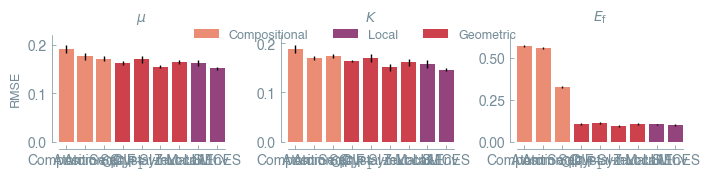

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden

# Use the provided mplstyle if available
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: lamalab.mplstyle not found. Using default Matplotlib style.")

# --- Constants ---
TWO_COL_WIDTH_INCH = 7.2
GOLDEN_RATIO = golden

# --- Mappings and Styles ---
REPRESENTATION_MAPPING = {
    'slices': 'SLICES',
    'crystal_text_llm': 'Crystal-text-LLM',
    'composition': 'Composition',
    'cif_p1': 'CIF P$_1$',
    'cif_symmetrized': 'CIF Sym.',
    'atom_sequences': 'Atom Seq.',
    'atom_sequences_plusplus': 'Atom Seq.++',
    'zmatrix': 'Z-Matrix',
    'local_env': 'Local-Env'
}

PROPERTY_DISPLAY_MAPPING = {
    'matbench_log_gvrh': r'$\mu$',
    'matbench_log_kvrh': r'$K$',
    'matbench_perovskites': r'$E_{\mathrm{f}}$'
}

GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': ['composition', 'atom_sequences_plusplus', 'atom_sequences']
    },
    'local': {
        'color': '#79155B',
        'members': ['local_env', 'slices']
    },
    'geometric': {
        'color':  '#c1121f',
        'members': ['crystal_text_llm', 'cif_symmetrized', 'cif_p1', 'zmatrix']
    }
}

def get_representation_group_and_color(representation):
    """Get the group and color for a given representation."""
    for group_name, group_info in GROUP_STYLES.items():
        if representation in group_info['members']:
            return group_name, group_info['color']
    return 'unknown', '#808080'  # Default gray for unknown representations

def apply_rangeframe(ax):
    """Apply rangeframe styling (remove top and right spines)."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))

def plot_30k_bar_results(data_30k, properties, output_filepath):
    """Create bar plots for 30K results across three properties."""
    
    num_properties = len(properties)
    
    # Calculate figure size
    subplot_width = TWO_COL_WIDTH_INCH / num_properties
    subplot_height = subplot_width / GOLDEN_RATIO * 1.2  # Slightly taller for bar plots
    
    fig, axes = plt.subplots(1, num_properties, 
                            figsize=(TWO_COL_WIDTH_INCH, subplot_height),
                            sharey=False)
    
    # If only one subplot, make it iterable
    if num_properties == 1:
        axes = [axes]
    
    # Get all available representations in the data (data structure is rep -> prop)
    available_representations = list(data_30k.keys())
    
    # Sort representations by group for better visual organization
    def get_group_order(rep):
        group, _ = get_representation_group_and_color(rep)
        group_order = {'compositional': 0, 'geometric': 1, 'local': 2, 'unknown': 3}
        return group_order.get(group, 3)
    
    available_representations.sort(key=get_group_order)
    
    for i, prop in enumerate(properties):
        ax = axes[i]
        
        # Collect data for this property
        rmse_means = []
        rmse_stds = []
        colors = []
        labels = []
        
        for rep in available_representations:
            try:
                # Correct data structure: data_30k[rep][prop]['rmse']
                if rep in data_30k and prop in data_30k[rep]:
                    rmse_stats = data_30k[rep][prop]['rmse']
                    rmse_means.append(rmse_stats['mean'])
                    rmse_stds.append(rmse_stats['std'])
                    
                    # Get color based on group
                    _, color = get_representation_group_and_color(rep)
                    colors.append(color)
                    labels.append(REPRESENTATION_MAPPING.get(rep, rep))
                else:
                    # Skip representations not available for this property
                    continue
            except KeyError:
                continue
        
        if not rmse_means:
            print(f"Warning: No data found for property {prop}")
            continue
        
        print(f"Property {prop}: Found {len(rmse_means)} representations")
        print(f"RMSE values: {rmse_means}")
            
        # Create bar positions
        x_pos = np.arange(len(rmse_means))
        
        # Create bars with error bars
        bars = ax.bar(x_pos, rmse_means, yerr=rmse_stds, 
                     color=colors, alpha=0.8, capsize=0,
                     #edgecolor='black', 
                     linewidth=0)
        
        # Customize the subplot
        ax.set_title(PROPERTY_DISPLAY_MAPPING.get(prop, prop), fontsize=10, pad=10)
        ax.set_ylabel('RMSE' if i == 0 else '', fontsize=9)
        
        # Set x-axis labels
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        
        # Apply rangeframe styling
        apply_rangeframe(ax)
        
        # Add grid for better readability
        ax.grid(False) #, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
        ax.set_axisbelow(True)
        
        # Set y-axis limits with some padding
        if rmse_means:  # Check if we have data
            y_max = max(rmse_means) + max(rmse_stds)
            ax.set_ylim(0, y_max * 1.1)
    
    # Create custom legend based on groups
    legend_elements = []
    for group_name, group_info in GROUP_STYLES.items():
        legend_elements.append(plt.Rectangle((0,0),1,1, 
                                           facecolor=group_info['color'], 
                                           alpha=0.8,
                                           #edgecolor='black',
                                           linewidth=0.0,
                                           label=group_name.capitalize()))
    
    # Add legend
    fig.legend(handles=legend_elements, 
              loc='upper center', 
              bbox_to_anchor=(0.5, 0.95),
              ncol=len(legend_elements), 
              frameon=False, 
              fontsize=9)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.25)  # Make room for legend and rotated labels
    
    # Save the plot
    plt.savefig(output_filepath, format=output_filepath.split('.')[-1], 
                dpi=300, bbox_inches='tight')
    if output_filepath.endswith('.png'):
        plt.savefig(output_filepath.replace(".png", ".pdf"), 
                   format='pdf', dpi=300, bbox_inches='tight')
    
    print(f"Bar plot saved to {output_filepath}")
    plt.show()

def load_30k_data_from_full_dataset(data_path):
    """Load and extract 30K data from the full dataset."""
    with open(data_path, 'r') as f:
        full_data = json.load(f)
    
    # Extract 30k data
    if '30k' in full_data:
        data_30k = full_data['30k']
        print(f"Found 30k data with representations: {list(data_30k.keys())}")
        # Print sample structure for debugging
        for rep in list(data_30k.keys())[:2]:  # First 2 representations
            print(f"Representation '{rep}' has properties: {list(data_30k[rep].keys())}")
        return data_30k
    else:
        print("Warning: 30k data not found in the dataset")
        print(f"Available keys in dataset: {list(full_data.keys())}")
        return {}

if __name__ == "__main__":
    # Update these paths according to your file locations
    data_size_path = "/Users/n0w0f/git/n0w0f/MATTEXT_FINAL_RESULTS/data_size_scaling_results.json"
    output_filename = "/Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/fig4/30k_barplot_results.png"
    
    # Properties to plot
    properties = ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
    
    # Load 30K data
    data_30k = load_30k_data_from_full_dataset(data_size_path)
    
    if data_30k:
        plot_30k_bar_results(data_30k, properties, output_filename)
    else:
        print("No data available to plot.")


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


Found 30k data with representations: ['local_env', 'cif_p1', 'cif_symmetrized', 'slices', 'crystal_text_llm', 'composition', 'atom_sequences', 'atom_sequences_plusplus', 'zmatrix']
Representation 'local_env' has properties: ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
Representation 'cif_p1' has properties: ['matbench_dielectric', 'matbench_log_kvrh', 'matbench_log_gvrh', 'matbench_perovskites']
Representations will be ordered as: ['atom_sequences', 'atom_sequences_plusplus', 'composition', 'local_env', 'slices', 'cif_p1', 'cif_symmetrized', 'crystal_text_llm', 'zmatrix']
Property matbench_log_gvrh: Found 9 representations
RMSE values: [0.17652471865383995, 0.17176157887686178, 0.19180570790595472, 0.16232222229181625, 0.15160335083329038, 0.16258828863570696, 0.17054343988066253, 0.15464148132729866, 0.16500466146175802]
Property matbench_log_kvrh: Found 9 representations
RMSE values: [0.17003189326664017, 0.17376810217545263, 0.18857737691230328, 0.1578109043148

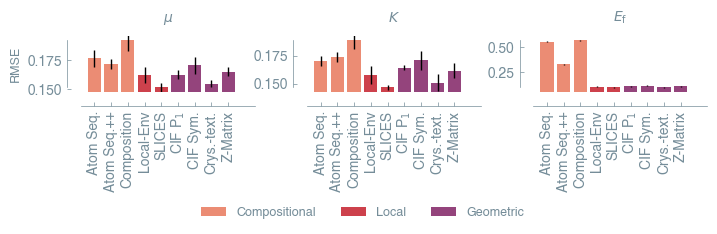

In [38]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden

# Use the provided mplstyle if available
try:
    plt.style.use("lamalab.mplstyle")
except OSError:
    print("Warning: lamalab.mplstyle not found. Using default Matplotlib style.")

# --- Constants ---
TWO_COL_WIDTH_INCH = 7.2
GOLDEN_RATIO = golden

# --- Mappings and Styles ---
REPRESENTATION_MAPPING = {
    'slices': 'SLICES',
    'crystal_text_llm': 'Crys.-text.',
    'composition': 'Composition',
    'cif_p1': 'CIF P$_1$',
    'cif_symmetrized': 'CIF Sym.',
    'atom_sequences': 'Atom Seq.',
    'atom_sequences_plusplus': 'Atom Seq.++',
    'zmatrix': 'Z-Matrix',
    'local_env': 'Local-Env'
}

PROPERTY_DISPLAY_MAPPING = {
    'matbench_log_gvrh': r'$\mu$',
    'matbench_log_kvrh': r'$K$',
    'matbench_perovskites': r'$E_{\mathrm{f}}$'
}

GROUP_STYLES = {
    'compositional': {
        'color': '#e76f51',
        'members': ['composition', 'atom_sequences_plusplus', 'atom_sequences']
    },
    'local': {
        'color': '#c1121f',
        'members': ['local_env', 'slices']
    },
    'geometric': {
        'color': '#79155B',
        'members': ['crystal_text_llm', 'cif_symmetrized', 'cif_p1', 'zmatrix']
    }
}

def get_representation_group_and_color(representation):
    """Get the group and color for a given representation."""
    for group_name, group_info in GROUP_STYLES.items():
        if representation in group_info['members']:
            return group_name, group_info['color']
    return 'unknown', '#808080'  # Default gray for unknown representations

def range_frame(ax, x, y, pad=0.1):
    y_min, y_max = np.array(y).min(), np.array(y).max()
    x_min, x_max = np.array(x).min(), np.array(x).max()
    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + 2*pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    #ax.spines["bottom"].set_bounds(x_min, x_max)
    ax.spines["left"].set_bounds(y_min, y_max)

def plot_30k_bar_results(data_30k, properties, output_filepath):
    """Create bar plots for 30K results across three properties."""
    
    num_properties = len(properties)
    
    # Calculate figure size
    subplot_width = TWO_COL_WIDTH_INCH / num_properties
    subplot_height = subplot_width / GOLDEN_RATIO # * 1.2  # Slightly taller for bar plots
    
    fig, axes = plt.subplots(1, num_properties, 
                            figsize=(TWO_COL_WIDTH_INCH, subplot_height),
                            sharey=False)
    
    # If only one subplot, make it iterable
    if num_properties == 1:
        axes = [axes]
    
    # Get all available representations in the data (data structure is rep -> prop)
    available_representations = list(data_30k.keys())
    
    # Sort representations by group for better visual organization
    # Order: compositional -> local -> geometric
    def get_group_order(rep):
        group, _ = get_representation_group_and_color(rep)
        group_order = {'compositional': 0, 'local': 1, 'geometric': 2, 'unknown': 3}
        return group_order.get(group, 3)
    
    # Sort by group first, then alphabetically within group for consistency
    available_representations.sort(key=lambda x: (get_group_order(x), x))
    
    print(f"Representations will be ordered as: {available_representations}")
    
    for i, prop in enumerate(properties):
        ax = axes[i]
        
        # Collect data for this property
        rmse_means = []
        rmse_stds = []
        colors = []
        labels = []
        
        for rep in available_representations:
            try:
                # Correct data structure: data_30k[rep][prop]['rmse']
                if rep in data_30k and prop in data_30k[rep]:
                    rmse_stats = data_30k[rep][prop]['rmse']
                    rmse_means.append(rmse_stats['mean'])
                    rmse_stds.append(rmse_stats['std'])
                    
                    # Get color based on group
                    _, color = get_representation_group_and_color(rep)
                    colors.append(color)
                    labels.append(REPRESENTATION_MAPPING.get(rep, rep))
                else:
                    # Skip representations not available for this property
                    continue
            except KeyError:
                continue
        
        if not rmse_means:
            print(f"Warning: No data found for property {prop}")
            continue
        
        print(f"Property {prop}: Found {len(rmse_means)} representations")
        print(f"RMSE values: {rmse_means}")
            
        # Create bar positions
        x_pos = np.arange(len(rmse_means))
        
        # Create bars with error bars
        bars = ax.bar(x_pos, rmse_means, yerr=rmse_stds, 
                     color=colors, alpha=0.8, capsize=0,
                     #edgecolor='black', 
                     #linewidth=0.5
                     )
        
        # Customize the subplot
        ax.set_title(PROPERTY_DISPLAY_MAPPING.get(prop, prop), fontsize=10, pad=10)
        ax.set_ylabel('RMSE' if i == 0 else '', fontsize=9)
        
        # Set x-axis labels with explicit rotation
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, fontsize=8)
        
        # Force rotation using setp for better control
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Apply rangeframe styling
        range_frame(ax, x_pos, rmse_means)
        
        # Add grid for better readability
        #ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
        ax.grid(False)
        ax.set_axisbelow(True)
        
        # Set y-axis limits with some padding
        # if rmse_means:  # Check if we have data
        #     y_max = max(rmse_means) + max(rmse_stds)
        #     ax.set_ylim(0, y_max * 1.1)
    
    # Create custom legend based on groups
    legend_elements = []
    for group_name, group_info in GROUP_STYLES.items():
        legend_elements.append(plt.Rectangle((0,0),1,1, 
                                           facecolor=group_info['color'], 
                                           alpha=0.8,
                                        #    edgecolor='black',
                                        #    linewidth=0.5,
                                           label=group_name.capitalize()))
    
    # Add legend
    fig.legend(handles=legend_elements, 
              loc='upper center', 
              bbox_to_anchor=(0.5, -0.35),
              ncol=len(legend_elements), 
              frameon=False, 
              fontsize=9)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    #plt.subplots_adjust(top=0.85, bottom=0.25)  # Make room for legend and rotated labels
    
    # Force rotation after layout adjustments (this should definitely work)
    for i in range(num_properties):
        ax = axes[i] if num_properties > 1 else axes
        for tick in ax.get_xticklabels():
            tick.set_rotation(90)
            tick.set_horizontalalignment('center')
    
    # Save the plot
    plt.savefig(output_filepath, format=output_filepath.split('.')[-1], 
                dpi=300, bbox_inches='tight')
    if output_filepath.endswith('.png'):
        plt.savefig(output_filepath.replace(".png", ".pdf"), 
                   format='pdf', dpi=300, bbox_inches='tight')
    
    print(f"Bar plot saved to {output_filepath}")
    plt.show()

def load_30k_data_from_full_dataset(data_path):
    """Load and extract 30K data from the full dataset."""
    with open(data_path, 'r') as f:
        full_data = json.load(f)
    
    # Extract 30k data
    if '30k' in full_data:
        data_30k = full_data['30k']
        print(f"Found 30k data with representations: {list(data_30k.keys())}")
        # Print sample structure for debugging
        for rep in list(data_30k.keys())[:2]:  # First 2 representations
            print(f"Representation '{rep}' has properties: {list(data_30k[rep].keys())}")
        return data_30k
    else:
        print("Warning: 30k data not found in the dataset")
        print(f"Available keys in dataset: {list(full_data.keys())}")
        return {}

if __name__ == "__main__":
    # Update these paths according to your file locations
    data_size_path = "/Users/n0w0f/git/n0w0f/MATTEXT_FINAL_RESULTS/data_size_scaling_results.json"
    output_filename = "/Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/fig4/30k_barplot_results.png"
    
    # Properties to plot
    properties = ['matbench_log_gvrh', 'matbench_log_kvrh', 'matbench_perovskites']
    
    # Load 30K data
    data_30k = load_30k_data_from_full_dataset(data_size_path)
    
    if data_30k:
        plot_30k_bar_results(data_30k, properties, output_filename)
    else:
        print("No data available to plot.")